In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [6]:
# 虚构一组线性回归的数据
np.random.seed(42)

x = np.arange(1, 100)

noise = np.random.normal(0, 5, size=len(x))

y = 3 + 2 * x + noise

df = pd.DataFrame({"x": x, "y": y})

df

,x,y
0,1,7.483571
1,2,6.308678
2,3,12.238443
3,4,18.615149
4,5,11.829233
...,...,...
94,95,191.039459
95,96,187.682425
96,97,198.480601
97,98,200.305276


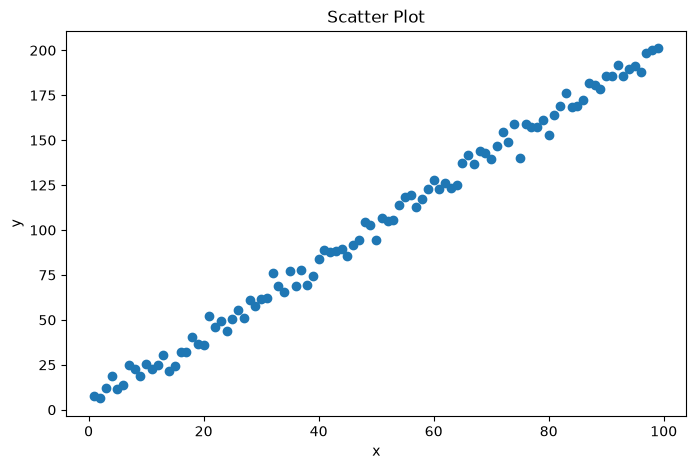

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df["x"], df["y"])

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Scatter Plot")

plt.show()

In [8]:
# 这个可以先不用看
X = sm.add_constant(df["x"])

model = sm.OLS(df["y"], X)

result = model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 1.552e+04
Date:                Wed, 19 Aug 2026   Prob (F-statistic):          7.48e-109
Time:                        10:05:08   Log-Likelihood:                -290.15
No. Observations:                  99   AIC:                             584.3
Df Residuals:                      97   BIC:                             589.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1082      0.928      2.272      0.0

In [9]:
# 划分训练数据和测试数据
X = df[["x"]]
y = df["y"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [10]:
from sklearn.linear_model import LinearRegression

# 1. 创建模型
model = LinearRegression()

# 2. 使用训练集拟合
model.fit(X_train, y_train)

# 3. 查看模型参数
print("回归系数:", model.coef_)
print("截距:", model.intercept_)

# 4. 对测试集进行预测
y_pred = model.predict(X_test)

print("预测值:")
print(y_pred)

print("真实值:")
print(y_test.to_numpy())

print(f"回归方程：y = {model.intercept_:.4f} " f"+ {model.coef_[0]:.4f}x")

回归系数: [2.01449929]
截距: 1.692691097901033
预测值:
[128.60614657  84.28716212 195.08462325  39.96817767 199.11362184
 172.92513103 132.63514516  88.31616071  23.85218332   3.70719039
  66.15666848 156.80913668  98.38865718  56.08417202  92.3451593
  11.76518756  48.02617484  27.88118191 180.9831282  150.7656388 ]
真实值:
[123.46832513  88.6923329  187.68242526  36.45987962 200.30527636
 168.95753199 137.06262911  88.42175859  22.68291154   7.48357077
  76.26139092 157.43523534 104.28561113  51.24503211  85.60739005
  11.82923313  49.33764102  30.20981136 178.35119898 158.82321828]
回归方程：y = 1.6927 + 2.0145x


In [11]:
import numpy as np

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"R²   = {r2:.4f}")
print(f"MAE  = {mae:.4f}")  # MAE：平均绝对误差
print(f"RMSE = {rmse:.4f}") # 均方根误差
print(f"MAPE = {mape:.2%}")  # 平均绝对百分比误差

R²   = 0.9940
MAE  = 3.8845
RMSE = 4.7455
MAPE = 6.93%


In [12]:
metrics_df = pd.DataFrame(
    {"Metric": ["R²", "MAE", "RMSE", "MAPE"], "Value": [r2, mae, rmse, mape]}
)

metrics_df

,Metric,Value
0,R²,0.993953
1,MAE,3.884490
2,RMSE,4.745481
3,MAPE,0.069339


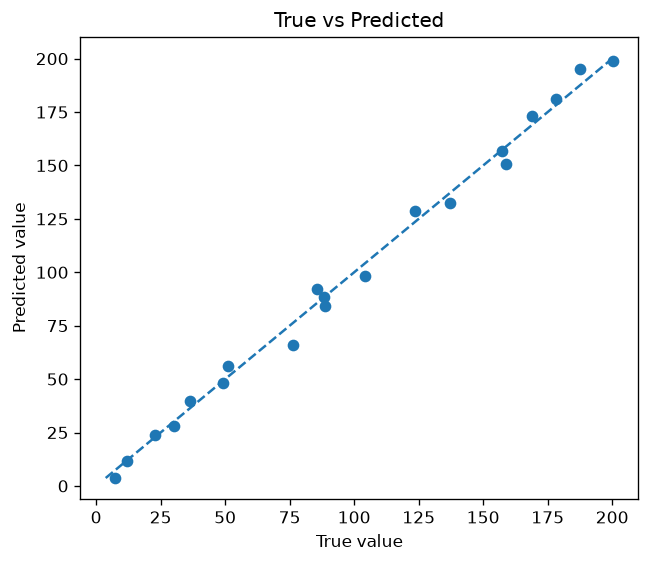

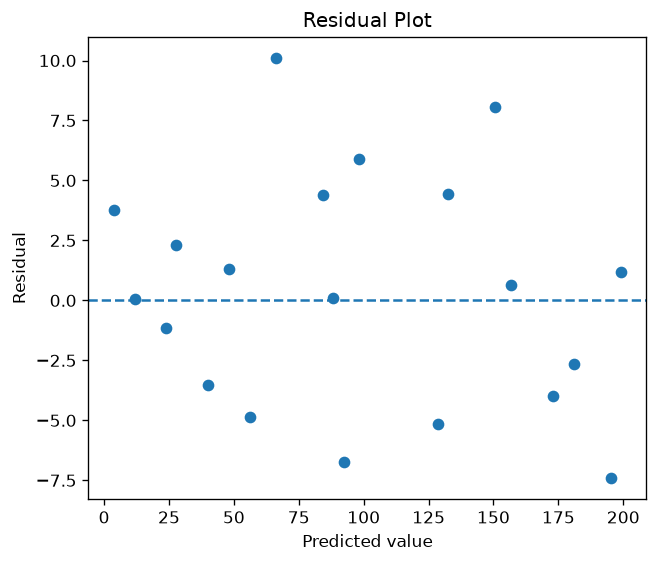

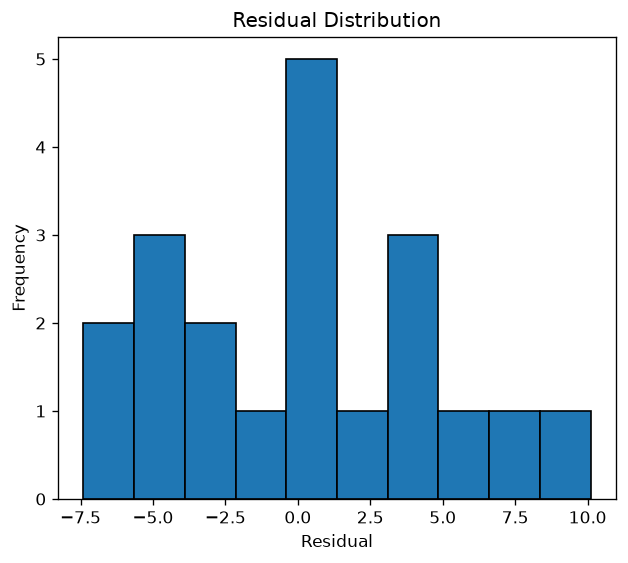

In [13]:
# 计算残差
residuals = y_test.to_numpy() - y_pred


# 1. 真实值 vs 预测值
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)

ax.scatter(y_test, y_pred)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

ax.set_xlabel("True value")
ax.set_ylabel("Predicted value")
ax.set_title("True vs Predicted")

plt.show()


# 2. 残差图
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)

ax.scatter(y_pred, residuals)
ax.axhline(y=0, linestyle="--")

ax.set_xlabel("Predicted value")
ax.set_ylabel("Residual")
ax.set_title("Residual Plot")

plt.show()


# 3. 残差分布
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)

ax.hist(residuals, bins=10, edgecolor="black")

ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.set_title("Residual Distribution")

plt.show()

In [14]:
# 计算残差
residuals = y_test - y_pred

print(residuals[0])

3.7763803738753454


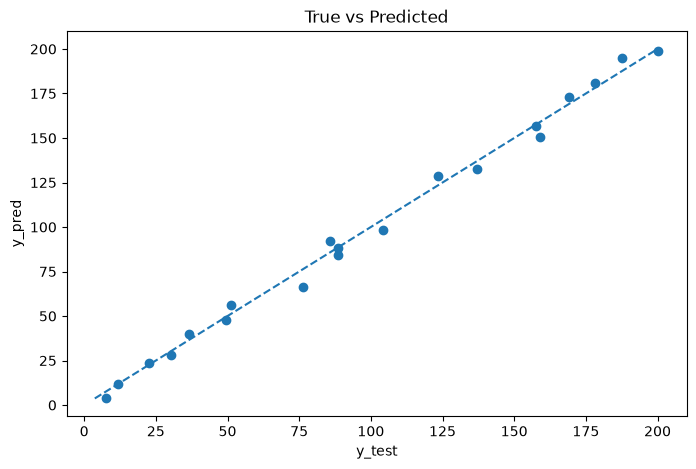

In [15]:
# 创建画布和坐标轴
fig, ax = plt.subplots(figsize=(8, 5))

# 横轴放真实值，纵轴放预测值
ax.scatter(y_test, y_pred)

# 设置坐标轴名称
ax.set_xlabel("y_test")
ax.set_ylabel("y_pred")

# 设置标题
ax.set_title("True vs Predicted")

# 找到真实值和预测值中的整体最小值、最大值
# 这样参考线能覆盖整张散点图
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

# 画理想参考线
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

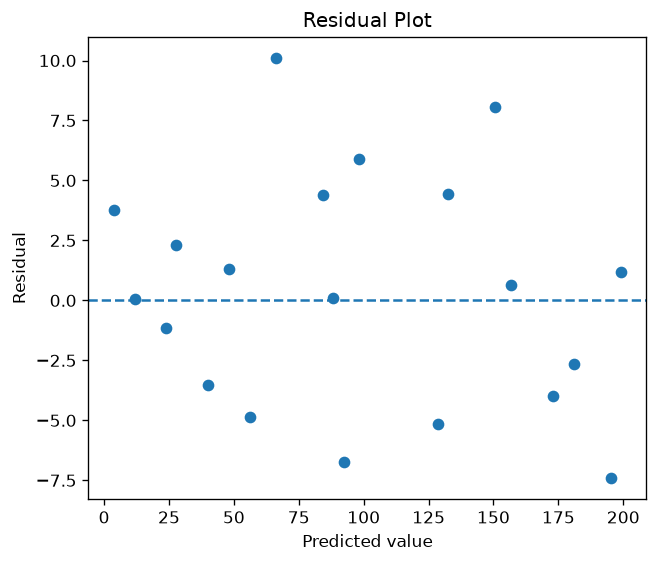

In [16]:
residuals = y_test.to_numpy() - y_pred

# 创建画布和坐标轴
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)

# 横轴：模型预测值
# 纵轴：对应样本的残差
ax.scatter(y_pred, residuals)

# 画残差 = 0 的参考线
# 残差 > 0：预测偏低
# 残差 < 0：预测偏高
ax.axhline(y=0, linestyle="--")

# 设置坐标轴和标题
ax.set_xlabel("Predicted value")
ax.set_ylabel("Residual")
ax.set_title("Residual Plot")

plt.show()

In [17]:
# 找到绝对残差最大的样本对应的原始索引
max_idx = pd.DataFrame(residuals).abs().idxmax()

# 给预测值重新加上 y_test 的原始索引
# 这样预测值就能和真实值、残差按照索引对应起来
y_pred_series = pd.Series(y_pred, y_test.index, name="y_pred")

print("原始索引:", max_idx)
print("真实值:", y_test.loc[max_idx])
print("预测值:", y_pred_series.loc[max_idx])
print("残差:", pd.DataFrame(residuals).loc[max_idx])

原始索引: 0    10
dtype: int64
真实值: 10    22.682912
Name: y, dtype: float64
预测值: 10    23.852183
Name: y_pred, dtype: float64
残差:             0
10  10.104722


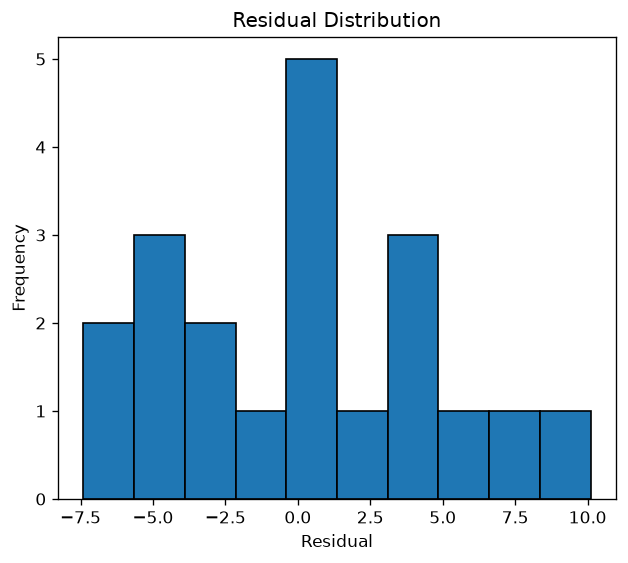

In [18]:
# 创建画布和坐标轴
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)

# 绘制残差分布直方图
# bins=10：把残差范围划分为 10 个区间
ax.hist(residuals, bins=10, edgecolor="black")

# 设置坐标轴和标题
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.set_title("Residual Distribution")

plt.show()

In [19]:
# 模型的整体解释能力
print("R² =", r2)

# 平均预测误差
print("MAE =", mae)

# 对大误差更敏感
print("RMSE =", rmse)  # RMSE > MAE

# 查看模型评价指标
print(f"R²   = {r2:.4f}")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")

R² = 0.9939526975368191
MAE = 3.884490495586937
RMSE = 4.745481068834844
R²   = 0.9940
MAE  = 3.8845
RMSE = 4.7455


R²：衡量模型相对于均值基准模型对因变量变异的解释程度，最大值为 1，但可以小于 0，不能解释为准确率。
MAE / RMSE：衡量预测误差大小，RMSE ≥ MAE，且 RMSE 对较大的误差更加敏感。
残差图：用于观察预测误差是否在 0 附近随机分布；若出现曲线、漏斗等明显结构，说明当前模型可能没有充分捕捉数据规律。

In [20]:
# 固定随机种子，保证每次运行生成的数据相同
np.random.seed(42)

# 生成 99 个样本的三个自变量
x1 = np.arange(1, 100)

# x2、x3 使用随机数据，避免和 x1 完全线性相关
x2 = np.random.uniform(0, 50, size=len(x1))
x3 = np.random.normal(20, 5, size=len(x1))

noise = np.random.normal(0, 5, size=len(x1))

# 人为设定真实的数据关系：
# y = 3 + 2*x1 - 1.5*x2 + 0.8*x3 + noise
y = 3 + 2 * x1 - 1.5 * x2 + 0.8 * x3 + noise

# 整理成 DataFrame：三个自变量，一个因变量
df = pd.DataFrame({"x1": x1, "x2": x2, "x3": x3, "y": y})

df

,x1,x2,x3,y
0,1,18.727006,12.906248,-12.036201
1,2,47.535715,25.212458,-50.982962
2,3,36.599697,24.517662,-30.144319
3,4,29.932924,20.095002,-13.430017
4,5,7.800932,17.327918,13.962964
...,...,...,...,...
94,95,38.548359,23.849887,147.756407
95,96,24.689780,26.341948,186.754227
96,97,26.136641,22.122431,182.109302
97,98,21.377051,24.702678,186.054505


In [21]:
# 指定自变量列
feature_cols = ["x1", "x2", "x3"]

# 指定因变量列
target_cols = "y"

# X 是特征矩阵：99 行 × 3 列
X = df[feature_cols]

# y 是目标变量
y = df[target_cols]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 创建多元线性回归模型
model = LinearRegression()

# 根据训练集学习三个自变量对应的系数
model.fit(X_train, y_train)

# 使用测试集进行预测
y_pred = model.predict(X_test)

# 查看截距
print("intercept =", model.intercept_)

# 将每一个变量和它的回归系数对应起来
coef_df = pd.DataFrame({"featrure": feature_cols, "coefficient": model.coef_})

coef_df

intercept = 7.782488626485616


,featrure,coefficient
0,x1,1.976058
1,x2,-1.525907
2,x3,0.667763


In [24]:
# 根据测试集预测值计算评价指标
r2 = r2_score(y_test, y_pred)

# 平均绝对预测误差
mae = mean_absolute_error(y_test, y_pred)

# 均方根误差，对较大的预测误差更加敏感
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 输出评价结果
print(f"R²=  {r2:.4f} ")
print(f"MAE=  {mae:.4f}")
print(f"RMSE= {rmse:.4f}")

R²=  0.9904 
MAE=  4.8711
RMSE= 5.7803


In [27]:
r2_multi = r2
mae_multi = mae
rmse_multi = rmse

# 从相同的训练集、测试集中，只取 x1
# 这样两个模型面对的是完全相同的样本，比较才公平
X1_train = X_train[["x1"]]
X1_test = X_test[["x1"]]

# 创建一元线性回归模型 
model_single = LinearRegression()

# 只使用x1训练模型
model_single.fit(X1_train, y_train)

# 在完全相同的测试样本上进行预测
y_pred_single = model_single.predict(X1_test)

# 计算一元模型的评价指标
r2_single = r2_score(y_test, y_pred_single)
mae_single = mean_absolute_error(y_test, y_pred_single)
rmse_single = np.sqrt(mean_squared_error(y_test, y_pred_single))

# 整理成一个表
compare_df= pd.DataFrame({
    "model":["x1 only", "x1+x2+x3"],
    "R²":[r2_single, r2_multi ],
    "mae":[mae_single, mae_multi],
    "rmse":[rmse_single,rmse_multi]
})

compare_df

,model,R²,mae,rmse
0,x1 only,0.835989,21.394599,23.885986
1,x1+x2+x3,0.990395,4.871129,5.780297
